# **AI 500 - PA4** 

## Overview
This assignment covers Causal Inference and Exploratory Data Analysis (EDA). Complete all questions and follow the submission rules below.


## Instructions
- Attempt **all questions**.  
- Run **every notebook cell** sequentially. For the coding questions, each cell must display its result (print values, show tables or visualizations).  
- For the analytical questions, write your answers in the markdown cell provided to you below each question.
- All necessary imports are already provided — do not make any more imports.
- Fill the top markdown cell with your **Full Name** and **Roll Number**.  
- Save your notebook exactly as `PA4_<your_roll_number>.ipynb` (example: `PA4_26100053.ipynb`).  
- Due date: **22 November 2025** (submit by 23:55).  
- Plagiarism is <span style="color:red">strictly prohibited — submit your own original work.</span>

Write your name and roll number here:
- `Name:` Mubeen Ahmed
- `Roll number:` 25280101

**Credit:** Based on the assignment developed during Dr. Ihsan Ayub Qazi's CS 334, Fall 2024 offering.


---

## **Part A - Analyzing the Impact of Castle Doctrine Laws on Violent Crime Rates**

### Introduction

The **Castle Doctrine** is a legal principle that grants individuals the right to use reasonable force, including deadly force, to defend themselves against an intruder within their own homes. Rooted in the notion that one's home is their "castle," these laws eliminate the duty to retreat before using force in self-defense. Proponents argue that the Castle Doctrine empowers lawful homeowners to protect themselves and deters criminal activity, while critics express concerns that such laws may escalate violence and lead to an increase in homicides.

Understanding the **causal relationship** between the implementation of Castle Doctrine laws and changes in violent crime rates is crucial for policymakers, law enforcement agencies, and communities. By analyzing this relationship, we can assess whether these laws effectively reduce crime or inadvertently contribute to higher rates of violence.

### Dataset Overview

This analysis utilizes a comprehensive dataset from the **FBI**, encompassing various states over multiple years. The dataset captures a wide range of variables related to violent crimes, socioeconomic conditions, and demographic factors. Notably, the implementation of Castle Doctrine laws occurred at different times across states, with the majority adopting these statutes around **2006**. This staggered adoption provides a unique opportunity to employ robust methodologies to isolate the effect of these laws on violent crime rates.

### Selected Columns for Analysis

For a focused and meaningful analysis, we restrict our examination to the following columns from the dataset:

| **Column**         | **Description**                                                                                                                                                                                                                 |
|--------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `year`             | The calendar year of the observation (e.g., 2005, 2010).                                                                                                                                                                       |
| `post`             | A binary indicator where `1` signifies the post-treatment period (after the implementation of Castle Doctrine laws) and `0` denotes the pre-treatment period.                                                                    |
| `sid`              | The state identifier, uniquely representing each state in the dataset.                                                                                                                                                       |
| `homicide`         | The number of homicides recorded in the state per 100,000 population for the given year.                                                                                                                                       |
| `robbery`          | The number of robberies reported in the state per 100,000 population for the given year.                                                                                                                                        |
| `larceny`          | The number of larcenies recorded in the state per 100,000 population for the given year.                                                                                                                                        |
| `assault`          | The number of aggravated assaults reported in the state per 100,000 population for the given year.                                                                                                                              |
| `burglary`         | The number of burglaries recorded in the state per 100,000 population for the given year. 
| `l_exp_pubwelfare`         | Logged public welfare spending                                                                                                                                        |
| `l_police`         | Logged police presence                                                                                                                                        |
| `l_income`         | Logged income                                                                                                                                        |
| `murder`           | The number of murders reported in the state per 100,000 population for the given year.                                                                                                                                          |
| `unemployrt`       | The unemployment rate in the state for the given year, serving as an economic indicator.                                                                                                                                          |
| `poverty`          | The poverty rate in the state for the given year, reflecting socioeconomic conditions.                                                                                                                                           |
| `blackm_15_24`     | The percentage of Black males aged 15-24 in the state for the given year.                                                                                                                                                        |
| `whitem_15_24`     | The percentage of White males aged 15-24 in the state for the given year.                                                                                                                                                        |
| `popwt`     | Population weight                                                                                                                                                                                                                       |

### **Crime Definitions**

To ensure clarity in our analysis, it's essential to define each of the key crime-related variables included in our dataset:

| **Variable**   | **Definition**                                                                                                                                                                                                                     |
|----------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Homicide**   | **Homicide** is defined as the sum of **murder** and **non-negligent manslaughter**. It represents the total number of intentional killings within a state, normalized per 100,000 state population.                                 |
| **Murder**     | **Murder** refers to the unlawful killing of another human being without justification or valid excuse, committed with the necessary intention as defined by the law in a specific jurisdiction.                                           |
| **Larceny**    | **Larceny** is the unlawful taking and carrying away of personal property with the intent to deprive the rightful owner of it permanently. It encompasses various forms of theft that do not involve force or intimidation.               |
| **Assault**    | **Assault** involves the act of causing physical harm or unwanted physical contact to another person. This includes aggravated assaults, which are more severe and may involve the use of weapons or intent to cause serious injury.       |
| **Burglary**   | **Burglary** is the act of illegally entering a building or other areas without permission, typically with the intention of committing a further criminal offense inside. It does not necessarily involve theft or violence.            |
| **Robbery**    | **Robbery** is the act of taking property or money from a person through force, intimidation, or threat of violence. Unlike larceny, robbery involves direct confrontation and coercion against the victim.                                |


### **Temporal and Spatial Dimensions**

The dataset spans multiple states across the United States and covers several years, allowing for a longitudinal analysis of crime trends in relation to the implementation of Castle Doctrine laws. Most states adopted these statutes around **2006**, but the exact year of implementation varies, providing a natural experiment setting to evaluate the laws' impact. By comparing states before and after the adoption period and against states that did not adopt the law during the study period, we can effectively employ different techniques to infer causality.

---



In [119]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import dowhy
from sklearn.linear_model import LinearRegression

Q1) Load `castle_doctrine_1.csv` into `df_1` and `castle_doctrine_2.csv` into `df_2`. Display the first 5 rows of `df_1` and last 5 rows of `df_2`.

In [120]:
df_1 = pd.read_csv('castle_doctrine_1.csv')
df_2 = pd.read_csv('castle_doctrine_2.csv')
print("First 5 rows of df_1:") # print first 5 rows of df_1
print(df_1.head())
print("\nFirst 5 rows of df_2:") # print first 5 rows of df_2
print(df_2.head())

First 5 rows of df_1:
    id    year   sid  post  l_exp_pubwelfare  l_police   l_income  unemployrt  \
0  575     NaN   6.0   0.0          6.774674  5.495338  10.821630    4.138185   
1  277  2002.0  27.0   0.0          6.807210  5.723646  10.650625    4.500000   
2  104  2005.0  11.0   0.0          7.077266  5.788776  10.845290    5.100000   
3  177  2001.0  18.0   0.0          7.218498  5.530656  10.765047    5.200000   
4  456  2005.0  43.0   0.0          7.487087  6.031345  10.692172    5.500000   

     poverty  blackm_15_24  whitem_15_24       popwt  
0  11.203561           NaN           NaN         NaN  
1  14.261345      0.754476     12.723339   921333.75  
2  14.413202      0.048599      0.298499  8871351.00  
3  14.815132      3.269265      5.064819  4105912.00  
4  15.560262      3.887660     13.213633  5885931.50  

First 5 rows of df_2:
   id  homicide    murder    robbery    assault    burglary    larceny
0   0  7.593978  6.532207  131.61357  325.61780   930.92017  2940.6

Q2.1) Store the total number of null values in both datasets in `nullTotal`.

In [121]:
nullTotal = df_1.isnull().sum().sum() + df_2.isnull().sum().sum()
print(f"Total number of null values in both datasets: {nullTotal}")



Total number of null values in both datasets: 157


Q2.2) Store the number of rows containing null values in both datasets in `rowsNull`.

In [123]:
rowsNull1 = df_1.isnull().any(axis=1).sum()
rowsNull2 = df_2.isnull().any(axis=1).sum()
rowsNull = rowsNull1 + rowsNull2
print(f"No. of rows having null value in df_1: {rowsNull1}")
print(f"No. of rows having null value in df_2: {rowsNull2}")
print(f"Total number of rows having null value : {rowsNull}")

No. of rows having null value in df_1: 30
No. of rows having null value in df_2: 0
Total number of rows having null value : 30


Q3) Drop all rows containing null values, and print the sizes of the resulting datasets.

In [124]:
df_1 = df_1.dropna()
df_2 = df_2.dropna()

print(f"Size of df_1 after dropping null values: {df_1.shape}")
print(f"Size of df_2 after dropping null values: {df_2.shape}")

Size of df_1 after dropping null values: (550, 12)
Size of df_2 after dropping null values: (550, 7)


Q4) Note that the id column in `df_1` is shuffled and not in order. Sort all the rows in the dataframe in ascending order using the `id` column.

In [125]:
df_1 = df_1.sort_values(by= 'id').reset_index(drop=True)
print("First 5 rows of sorted df_1:")
print(df_1.head())

First 5 rows of sorted df_1:
   id    year  sid  post  l_exp_pubwelfare  l_police   l_income  unemployrt  \
0   0  2000.0  1.0   0.0          6.926083  5.854609  10.711102         4.1   
1   1  2001.0  1.0   0.0          6.974412  5.863135  10.675931         4.7   
2   2  2002.0  1.0   0.0          7.038751  5.741382  10.727071         5.4   
3   3  2003.0  1.0   0.0          7.110424  5.853816  10.695688         5.5   
4   4  2004.0  1.0   0.0          7.085519  5.792754  10.652069         5.1   

     poverty  blackm_15_24  whitem_15_24      popwt  
0  14.705981      2.222243      4.694810  4499293.0  
1  15.750203      2.249954      4.700201  4499293.0  
2  15.556559      2.258261      4.685461  4499293.0  
3  15.447802      2.292948      4.688166  4499293.0  
4  16.252654      2.291327      4.661734  4499293.0  


Q5.1) The dataset is split across two files; both files share an `id` column with identical row counts and therefore, a one-to-one mapping — join them on `id` and store the merged table in a variable named `df`.

In [126]:
df = pd.merge(df_1, df_2, on='id') # merge both dataframes on 'id' column
print("First 5 rows of merged dataframe df:")
print(df.head())


First 5 rows of merged dataframe df:
   id    year  sid  post  l_exp_pubwelfare  l_police   l_income  unemployrt  \
0   0  2000.0  1.0   0.0          6.926083  5.854609  10.711102         4.1   
1   1  2001.0  1.0   0.0          6.974412  5.863135  10.675931         4.7   
2   2  2002.0  1.0   0.0          7.038751  5.741382  10.727071         5.4   
3   3  2003.0  1.0   0.0          7.110424  5.853816  10.695688         5.5   
4   4  2004.0  1.0   0.0          7.085519  5.792754  10.652069         5.1   

     poverty  blackm_15_24  whitem_15_24      popwt  homicide    murder  \
0  14.705981      2.222243      4.694810  4499293.0  7.593978  6.532207   
1  15.750203      2.249954      4.700201  4499293.0  8.713443  7.494940   
2  15.556559      2.258261      4.685461  4499293.0  6.933288  6.406999   
3  15.447802      2.292948      4.688166  4499293.0  6.818007  6.567177   
4  16.252654      2.291327      4.661734  4499293.0  5.753689  5.595123   

     robbery    assault    burglary  

Q5.2) We do not need the `id` column any longer. Drop the `id` column.

In [127]:
df = df.drop(columns=['id'])
print(f"\nColumns in merged dataframe after dropping 'id': {df.columns.tolist()}")
print(f"Size of merged dataframe df: {df.shape}")


Columns in merged dataframe after dropping 'id': ['year', 'sid', 'post', 'l_exp_pubwelfare', 'l_police', 'l_income', 'unemployrt', 'poverty', 'blackm_15_24', 'whitem_15_24', 'popwt', 'homicide', 'murder', 'robbery', 'assault', 'burglary', 'larceny']
Size of merged dataframe df: (550, 17)


Q6.1) Plot a correlation heatmap for this dataset using the `selected_columns` (it should be a color coded graph indicating correlation values for each of the columns against every other column).

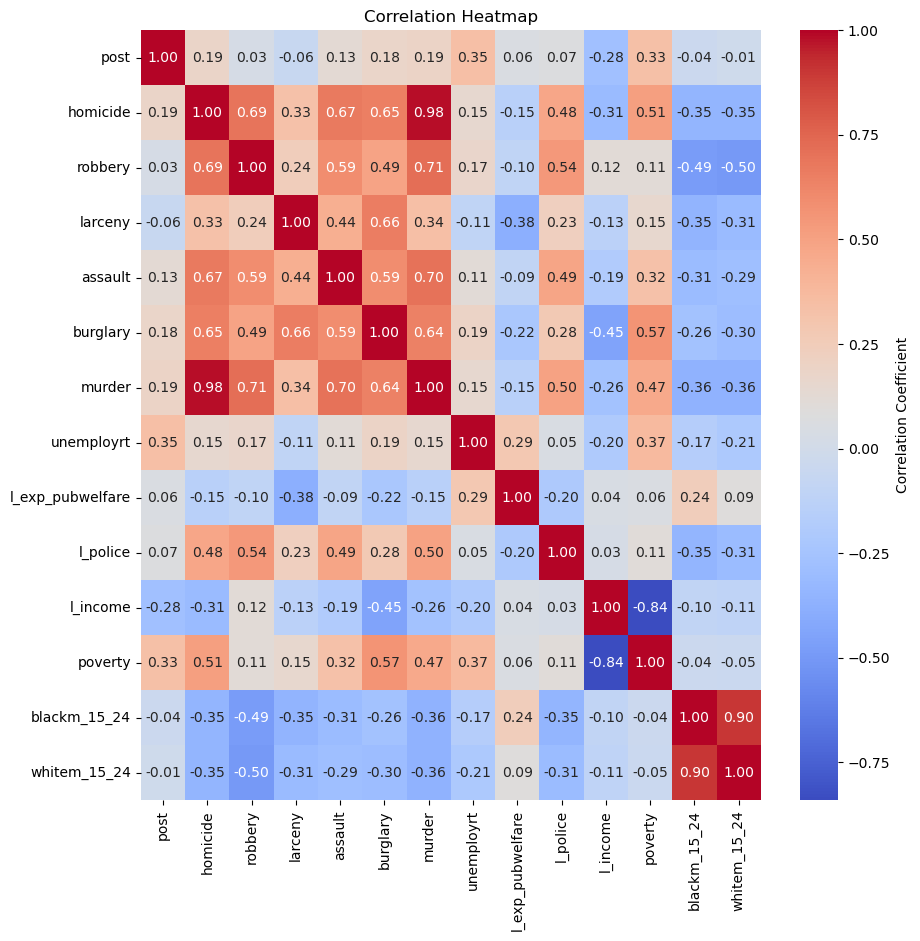

In [128]:
selected_columns = ['post', 'homicide', 'robbery', 'larceny', 
                    'assault', 'burglary', 'murder', 'unemployrt','l_exp_pubwelfare' ,'l_police','l_income',
                    'poverty', 'blackm_15_24', 'whitem_15_24']


# estimate the correlation matrix 
corr_matrix = df [selected_columns].corr()

# plot heatmap
plt.figure(figsize = (10,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap')
plt.show()

Q6.2) Comment on any 3 notable correlations. Based on these correlations, can you say that any of the correlations you suggested are causally related? If so, is their causal relationship direct or indirect, and are there any cofounding variables you suspect? Otherwise, explain why you weren't able to deduce any causal relaion.

Note: You will be graded on how critically you have commented, not how much you write. So keep your answers crisp and to the point, but also think deeply. 

<span style="color:lightgreen"> Answer: </span> Firstly there is near perfect correlation ( = 0.98) between homocide and murder, this relationship is not causal rather structural in nature as homocide is the sum of murder and non-negligent manslaughter. It is just structural relationship, based on how these variables are defined therefore no causality and no confounders are present. 

Secondly, there is very strong but negative correlation value for logged income and poverty (= -0.84), this negative indicates that with increase in income the level of poverty goes down, which is true as per economic principles, furthermore, there exists possibility of direct causality as  increase in income pushes people out of poverty, but there are many confounders that effects both these variables, for example , education, employment, and descrimination based on gender and race, moreover, this decision can not be solely based on correlation coeffiecent. 

Thirdly, there is storng positive association between murder and robbery (=0.71) though there is high correlation because both of these crimes occur in similar crimogenic conditions, but this does translate into direct causal link. As the primary driver of these crimes are third factors i.e. poverty, and unemployment. 

Q7.1) Estimate the average treatment effect on Homicide before and after the doctrine was implemented using the post attribute in your dataset, without conditioning on any variable. Store your answer in the `ATE` variable.

In [129]:
ATE = df [df['post'] == 1]['homicide'].mean() - df[df['post'] == 0]['homicide'].mean()
print(f"Avergae treatment effect (ATE) on homicide : {ATE:.4f}")



Avergae treatment effect (ATE) on homicide : 1.3488


Q7.2) What might the issue with the calculated ATE?

<span style="color:lightgreen"> Answer: </span>  The issue with this calculated ATE are the confunding variables and selection bias , as ATE compares the average homicide rate in all states after the law was implimented to before and this difference is likely to be influenced by many variables other than law, which act as confounder includng the time trend and socio econoimc variables. Furthermore, the there is no as such treatment group rather it compares the before and after results which is not good enough for the causlity when there is selection bias , hence more robust approach i.e. Difference in DIfference (DID) is required.

Q8) Create a plot that shows the number of observations in the pre-treatment and post-treatment periods. Make sure your graph is properly labelled.

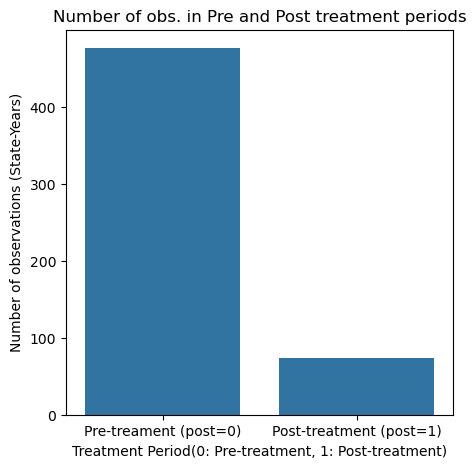

In [57]:
plt.figure(figsize=(5,5))
sns.countplot(x='post', data=df)
plt.title('Number of obs. in Pre and Post treatment periods')
plt.xlabel('Treatment Period(0: Pre-treatment, 1: Post-treatment)')
plt.ylabel('Number of observations (State-Years)')
plt.xticks([0,1], ['Pre-treament (post=0)', 'Post-treatment (post=1)'])
plt.show()

Q9.1) For the states that implemented the doctrine, use an appropriate plot to visualise the number of observations for the 5 states with the highest number of overall samples (pre and post). In the plot, separate counts for pre and post-treatment periods.

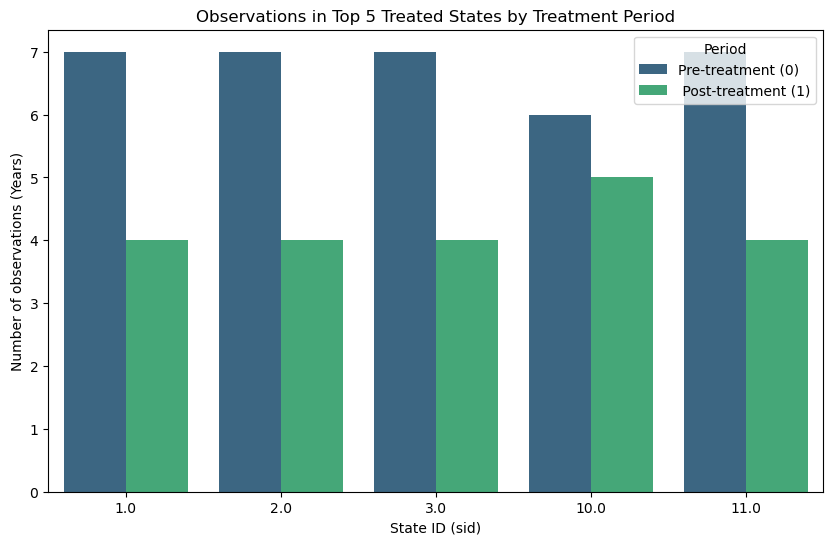

In [130]:
# filter for treated states 
treated_sids = df[df['post'] == 1]['sid'].unique()
df_treated = df[df['sid'].isin(treated_sids)]

# get 5 states with the highest numbers of total samples 
top_5_sids = df_treated['sid'].value_counts().nlargest(5).index.tolist()
df_top5 = df_treated[df_treated['sid'].isin(top_5_sids)]

# plotting 
plt.figure(figsize=(10,6))
sns.countplot(x= 'sid', hue='post', data=df_top5, palette='viridis')
plt.title('Observations in Top 5 Treated States by Treatment Period')
plt.xlabel('State ID (sid)')
plt.ylabel('Number of observations (Years)')
plt.legend(title='Period', labels=['Pre-treatment (0)', ' Post-treatment (1)' ])
plt.show()


Q9.2) Since our dataset comprises of data from many states, we want to calculate the per state ATE. Before we do that, we are interested in the ATE of the states with more data samples. Therefore, calculate the per state ATE of the 5 states you've visualised above and display the results in a dataframe.

In [ ]:
ate_per_state = (
    df_top5
    .groupby('sid')[['post', 'homicide']]
    .apply(lambda g: g.loc[g['post'] == 1, 'homicide'].mean() 
                    - g.loc[g['post'] == 0, 'homicide'].mean())

    .reset_index(name='ATE_homicide_per_state')
)
print("ATE for the top 5 samples states:")
print(ate_per_state)

ATE for the top 5 samples states:
    sid  ATE_homicide_per_state
0   1.0               -0.222152
1   2.0               -0.962524
2   3.0               -0.531949
3  10.0                0.534881
4  11.0               -0.631924


Q9.3) Compute the overall CATE as follows:
- Select states that were treated in 2010.
- For each selected state, compute the state-level ATE on homicide:

Using the state-level ATEs, compute the CATE and report it.

In [138]:
# staes treated in 2010
states_treated_in_2020 = df[(df['post'] == 1) & (df['year'] == 2010)]['sid'].unique()
# number of states treated in 2010
num_treated_2010 = len(states_treated_in_2020)
print(f"Number of states treated in 2010: {num_treated_2010}")

# filter dataframe for these states treated in 2010
df_treated_2010 = df[df['sid'].isin(states_treated_in_2020)]

# compute ATE for these states
state_ate_2010 = ( 
    df_treated_2010
    .groupby('sid') 
    .apply(
        lambda g: g[g['post'] == 1] ['homicide'].mean() 
        - g[g['post'] == 0] ['homicide'].mean(),
        include_groups=False
    )
    .reset_index(name='State_ATE_Homocide') 
)
# compute CATE (COnditional ATE) by averaging ATEs
CATE = state_ate_2010['State_ATE_Homocide'].mean() 
print(f"CATE for states treated in 2010: {CATE:.4f}")



Number of states treated in 2010: 21
CATE for states treated in 2010: -0.2084


Q9.4) Do you observe any evidence for the Simpson's Paradox for any individual state? If so, why do you think this might be the case?

<span style="color:lightgreen"> Answer: </span> The simpson paradox is present for the state 10, as it has positve ATE ( increase in the homocide post treatment), while most other states show negative ATEs (i.e. decrease in homocide), so when average across all these states is computed the overall CATE becomes negative because the larger negative effect dominates the results, which is the calssical case of Simpson's paradox ( the aggreate trends are different from individual trends). 

Q10) Now, report the ATE on Homicide using the DiD (Difference in Difference) formula where:

-   Assume the pre-intervention period is 2005, while the post-intervention period is 2010,
-   Given S defines your set of all states, your treatment group T consists of the states that have implemented the doctrine in 2010, and your control group are the states S\T in 2005 (i.e. the states apart from those incorporated in T)


In [144]:
# states treated in 2010
treated_in_2010 = df[(df['post'] == 1) & (df['year'] == 2010)]['sid'].unique()
df_did = df[df['year'].isin([2005, 2010])].copy() # filter for years 2005 and 2010

df_did['treatment_group'] = df_did['sid'].apply(lambda x: 1 if x in treated_in_2010 else 0)

# calcualte the means 
y_t_post = df_did[(df_did['treatment_group'] == 1) & (df_did['year'] == 2010)]['homicide'].mean()
y_t_pre = df_did[(df_did['treatment_group'] == 1) & (df_did['year'] == 2005)]['homicide'].mean()
y_c_post = df_did[(df_did['treatment_group'] == 0) & (df_did['year'] == 2010)]['homicide'].mean()
y_c_pre = df_did[(df_did['treatment_group'] == 0) & (df_did['year'] == 2005)]['homicide'].mean()


# calculate DID estimate
DID_estimate = (y_t_post - y_t_pre) - (y_c_post - y_c_pre)
print(f"DID estimate for homicide rate: {DID_estimate:.4f}")


print(f"Mean homicide rate in treated states pre-treatment: {y_t_pre:.4f}") 
print(f"Mean homicide rate in treated states post-treatment: {y_t_post:.4f}")
print(f"Mean homicide rate in control states pre-treatment: {y_c_pre:.4f}")
print(f"Mean homicide rate in control states post-treatment: {y_c_post:.4f}")


DID estimate for homicide rate: 0.1313
Mean homicide rate in treated states pre-treatment: 5.7743
Mean homicide rate in treated states post-treatment: 5.1323
Mean homicide rate in control states pre-treatment: 4.2384
Mean homicide rate in control states post-treatment: 3.4651


Q11) Plot the overall average homicides per year in appropriate graph.

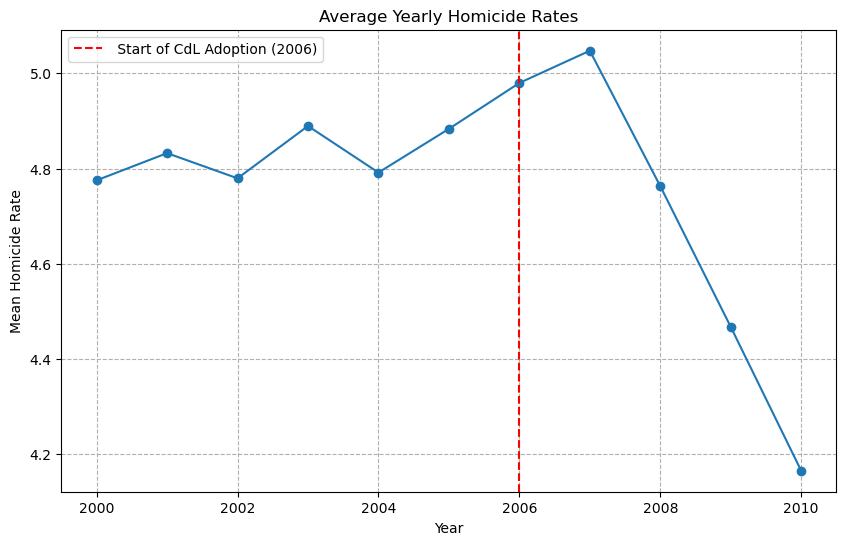

In [ ]:
mean_yearly_homicide = (
    df
    .groupby('year')['homicide'] # group by year 
    .mean()
    .reset_index()
)   

plt.figure(figsize=(10,6))

plt.plot(mean_yearly_homicide['year'],
         mean_yearly_homicide['homicide'], 
         marker='o')

# most states adopted law in 2006 ( given in the context)
plt.axvline(x=2006, color='red', linestyle='--', label = ' Start of CdL Adoption (2006)')


plt.title('Average Yearly Homicide Rates')
plt.xlabel('Year')
plt.ylabel('Mean Homicide Rate')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

Q12) Synthesize the results from your analyses (correlation heatmap, raw ATE, per‑state ATEs, CATE, DiD, plots). Based on this evidence, state whether you believe the Castle Doctrine had a causal effect, positive or negative, on homicide rates and justify your conclusion with specific findings. Then list the main limitations and identification threats in your approach.

Cite specific results (numbers or trends) that support or contradict a causal effect.
Identify likely confounders and how they could bias estimates.
Note methodological limitations (e.g., aggregated vs. within‑state effects, parallel trends assumption for DiD).

(There is no correct answer for this question so please be thorough in your response).

<span style="color:lightgreen"> Answer: </span>
Based on the estimates and the analysis the reuslts show that there exists causal relationship between the implementation of Castle Doctrine and the homocide rates, homocide rates increases as the result of implementation of this doctrine, specifically **DID ATE has value 0.1313**, which indicate though this causal effect is small in magnitude it is still significant after controlling for the confounders.  The group wise anlaysis for the control states also experience **decline in the homocide (-0.773) which is higher than than of the treated states (-0.6420)**. The DID reesults are positive suggesting that positive directly effected the homocide increasing them , or the decline was driven by the national trend. 

There are some limitations to the robusness of methodological approach as well, **Parallel Trends assumption** which assume thet the treated states would have followed the same patterns and trends as that of control states in the absence of law, but this is often violated due to presence of various confounders including poverty and unemployment which has strong correlation with homocide ( corr b/w poverty and homocide = 0.51), furthermore, rlying on two points ie. 2010 and 2005 limtise the idea to check fot the  existence of the parallel trends before the implementation of the law, or before intervention. 


## **Part B - Analyzing the Impact of Digital Notes on GPA**

We tested whether taking notes digitally affects students' GPA. In an experiment with 1,000 students we recorded a binary indicator for digital note-taking, measured each student's change in GPA after one year, and logged weekly study hours (scaled). Use the file `digital_notes.csv` for the analysis. For this task, we will be using the `doWhy` library. Please refer to the documentation to solve this part: https://www.pywhy.org/dowhy/v0.13/getting_started/index.html.

Q13) Start by loading the data into a dataframe and displaying the first 5 rows of it.

In [111]:
df_notes = pd.read_csv('digital_notes.csv')
print("First 5 rows of digital_notes:")
print(df.notes.head())



First 5 rows of digital_notes:
   study_hours  digital_notes  effect_on_gpa
0    -0.228014          False      -0.116390
1     1.448314          False       0.793924
2     1.919683           True       1.555616
3     1.801566          False       0.991375
4     1.684526           True       1.425603


Q14) Plot the number of students who used digital notes versus those who did not. Use a clearly labeled plot, include a title and axis labels, and display the plot.

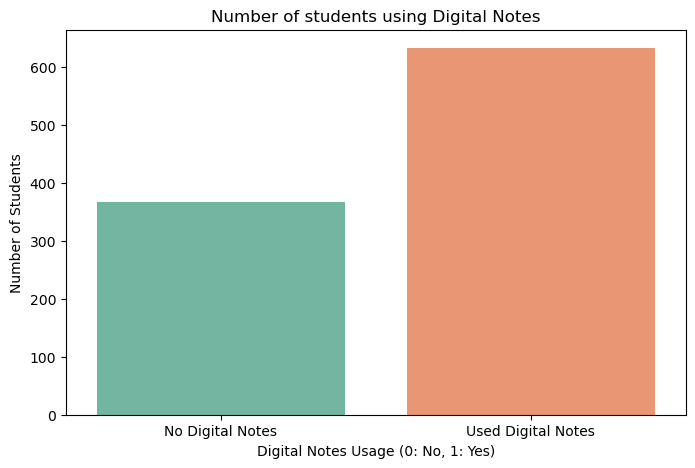

In [112]:
plt.figure(figsize=(8,5))
sns.countplot(x='digital_notes', data=df_notes, palette='Set2', hue='digital_notes', legend=False)
plt.title('Number of students using Digital Notes')
plt.xlabel('Digital Notes Usage (0: No, 1: Yes)')
plt.ylabel('Number of Students')
plt.xticks([0,1], ['No Digital Notes', 'Used Digital Notes'])
plt.show()

Q15.1) Althought counterintuitive at first, we make an informed hypothesis that weekly study hours could affect both digital note usage and GPA (think about what this means). Use this information and the given data to generate a `CausalModel` using the `doWhy` library. Visualise the constructed model.

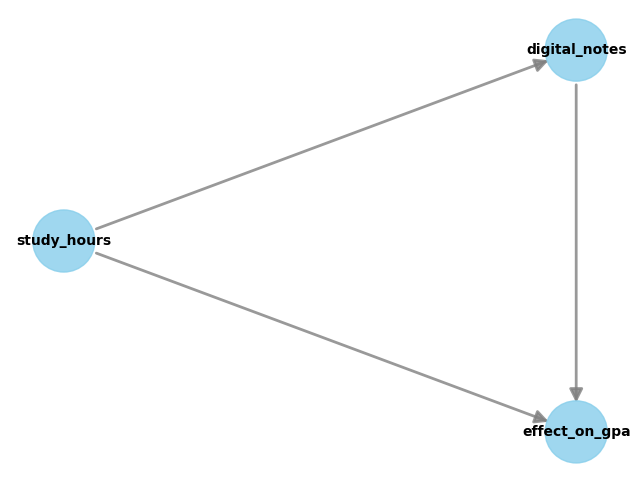

In [113]:
# build the causal model
from dowhy import CausalModel
model = CausalModel(
    data=df_notes,
    treatment='digital_notes',
    outcome='effect_on_gpa',
    common_causes=['study_hours']
)

model.view_model() # to visualize the constructed model

Q15.1) What is the confounding variable in our experiment? 

<span style="color:lightgreen"> Answer: </span>
In this experiemnt study hours is acting as the confounder, as DAG ( directed caual diagram) also show that the study hurs effects both the treatment and the outcome variables which are digital_notes and effect_on_gpa, confouning the causal relationship between them. As the sudy_hours is effecting both so the raw difference between these groups will be bias as the result of studying on just because of digital notes. 

Q15.2) Use the constructed DAG to list all possible frontdoor and backdoor paths.

<span style="color:lightgreen"> Answer: </span>
The Causal Diagram show that study_hours is confounder effecting both the treatment(digital_notes) and the control (gpa) 
$$\text{digital\_notes} \leftarrow \mathbf{\text{study\_hours}} \rightarrow \text{effect\_on\_gpa}$$

For the **Backdoor Path** (i.e. path from treatment to outcome),it is open as it contain the confounder ( study-hours) which intrduces the bias, and suproisous relationship, hence confounder (study_hours) need to be controlled for so that **this path of the reverse cusality with confounder that can be controlled. 

For the **Frontdoor Paths** there is no frondoor path , as there is no mediating variable present, the given variable study_hours is the confounder not the **mediating (intermediate) variable**. Therefore the frontdoor path as such cannnot be used to establish the causal link here. 


Q16) Compute and report the ATE of digital note-taking on GPA using the dataframe.

In [114]:
unadjusted_ATE_df = df_notes[df_notes['digital_notes'] == 1]['effect_on_gpa'].mean() - df_notes[df_notes['digital_notes'] == 0]['effect_on_gpa'].mean()
print(f"Unadjusted ATE of digital notes on GPA change: {unadjusted_ATE_df:.4f}")


Unadjusted ATE of digital notes on GPA change: 0.7619


Q17) Use the `doWhy` library to identify the effects of each variable and then print the identified estimand. (this is just one line of code -> read the documentation carefully)

In [115]:
model = CausalModel(
    data=df_notes,
    treatment='digital_notes',
    outcome='effect_on_gpa',
    common_causes=['study_hours']
)   

identified_estimand = model.identify_effect()
print("Identified_estimand:")
print(identified_estimand)

Identified_estimand:
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                     
───────────────(E[effect_on_gpa|study_hours])
d[digitalₙₒₜₑₛ]                              
Estimand assumption 1, Unconfoundedness: If U→{digital_notes} and U→effect_on_gpa then P(effect_on_gpa|digital_notes,study_hours,U) = P(effect_on_gpa|digital_notes,study_hours)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
       d                                     
───────────────(E[effect_on_gpa|study_hours])
d[digitalₙₒₜₑₛ]                              
Estimand assumption 1, Unconfoundedness: If U→{digital_notes} and U→effect_on_gpa then P(effect_on_gpa|digital_notes,study_hours,U) = P(effect_on_gpa|digital_notes,study_hours)



Q18) Using the identified estimate, use linear regression from `doWhy` to predict the causal estimate. 

In [116]:
causal_dowhy = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)
print("Linear Regression (causal_dowhy):")
print(causal_dowhy)
print(f"\n Estimated Causal effect  ( ATE): {causal_dowhy.value:.4f}")


Linear Regression (causal_dowhy):
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                     
───────────────(E[effect_on_gpa|study_hours])
d[digitalₙₒₜₑₛ]                              
Estimand assumption 1, Unconfoundedness: If U→{digital_notes} and U→effect_on_gpa then P(effect_on_gpa|digital_notes,study_hours,U) = P(effect_on_gpa|digital_notes,study_hours)

## Realized estimand
b: effect_on_gpa~digital_notes+study_hours
Target units: ate

## Estimate
Mean value: 0.49981452592098596


 Estimated Causal effect  ( ATE): 0.4998


Q19.1) We will now calculate the ATE using `LinearRegression` from the `sklearn` library. Do this without adjusting for the confounding variables first.

In [117]:
# unadjested model 
unadj_x = df_notes[['digital_notes']]  
y = df_notes['effect_on_gpa']

unad_lnreg = LinearRegression()
unad_lnreg.fit(unadj_x, y)

unad_ate_lnreg = unad_lnreg.coef_[0] # the coefficient for the  digital_notes in the unadjsted ATE 

print(f"Unadjusted ATE from Linear Regression (coeff. for digital notes): {unad_ate_lnreg:.4f}")

Unadjusted ATE from Linear Regression (coeff. for digital notes): 0.7619


Q19.2) Now, predict the ATE with adjustment for the confounding variable.

In [118]:
# adjuested model with study_hours as confounder
adj_x = df_notes[['digital_notes', 'study_hours']]
y = df_notes['effect_on_gpa']

adj_lnreg = LinearRegression()
adj_lnreg .fit(adj_x, y)

# the coefficient for digital_notes in the adjusted model
adj_ate_lnreg = adj_lnreg.coef_[0]
print(f"Adjusted ATE from Linear Regression (coeff. for digital notes): {adj_ate_lnreg:.4f}")


Adjusted ATE from Linear Regression (coeff. for digital notes): 0.4998


Q20) Compare the unadjusted ATE and the ATE adjusted for study_hours. Report the numeric difference, explain why they differ, and state whether the evidence suggests digital note-taking improves GPA.

<span style="color:lightgreen"> Answer: </span> 
Unadjusted ATE = **0.7619**

Adjusted ATE  = **0.4998**

Difference  = Unadjusted ATE - Adjusted ATE  = 0.7619 - 0.4998 = **0.2621** 

The difference is due to the study hours acting as the potential positive confounder,  so in the  unadjusted model the students who use digital notes tends to spend more hours studying, while the adjusted model isolates the confounder i.e. study_hours, removing the bias and giving out the actual effects of the digital notes, suggesting that the taking digital notes results in the change in the gpa.  
